## Project Imports

Import the libraries required for file-system operations, reproducible random operations, numerical calculations, neural-network training, image preprocessing, data loading, evaluation, and result visualization.

In [52]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

## Reproducibility Setup

Set the same random seed for Python, NumPy, and PyTorch so that dataset shuffling, train-validation splitting, and model initialization produce reproducible results.

In [53]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Dataset Loading and Initial Inspection

Define the dataset directory, verify that it exists, resize every image to 224 × 224 pixels, convert images into PyTorch tensors, and load the three visual classes with `ImageFolder`. Inspect the dataset size, class-to-index mapping, and one sample image.

In [54]:
DATA_DIR = Path(r"C:\Users\ermak\Desktop\slot_style_classifier\data\processed_3styles")  

print("Checking folder:", DATA_DIR.resolve())
print("Folder exists?", DATA_DIR.exists())

tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

ds = datasets.ImageFolder(root=str(DATA_DIR), transform=tfm)

print("\n--- Dataset Information ---")
print("Number of images:", len(ds))
print("Classes (folder names):", ds.classes)
print("Class-to-index mapping:", ds.class_to_idx)
x, y = ds[0]

print("\n--- One sample (ds[0]) ---")
print("x shape:", x.shape)                 
print("x dtype:", x.dtype)
print("x min/max:", float(x.min()), float(x.max()))  
print("label y:", y, "=> class:", ds.classes[y])

Checking folder: C:\Users\ermak\Desktop\slot_style_classifier\data\processed_3styles
Folder exists? True

--- Dataset Information ---
Number of images: 303
Classes (folder names): ['Dominant_Characters', 'Iconic_Symbols', 'Secondary_Character_Symbols']
Class-to-index mapping: {'Dominant_Characters': 0, 'Iconic_Symbols': 1, 'Secondary_Character_Symbols': 2}

--- One sample (ds[0]) ---
x shape: torch.Size([3, 224, 224])
x dtype: torch.float32
x min/max: 0.0 1.0
label y: 0 => class: Dominant_Characters


## Current Working Directory Check

Display the notebook's current working directory to understand how Python resolves relative file paths.

In [55]:
print("Current working directory (cwd):", os.getcwd())
print("Same path using Path:", Path.cwd())

Current working directory (cwd): c:\Users\ermak\Desktop\slot_style_classifier — копия (2)\notebooks
Same path using Path: c:\Users\ermak\Desktop\slot_style_classifier — копия (2)\notebooks


## Relative Dataset Path Check

Test how a relative dataset path is resolved from the notebook directory and verify whether the target folder exists.

In [56]:
DATA_DIR = Path("../data/processed_3styles")  
print("Path:", DATA_DIR)
print("Absolute path:", DATA_DIR.resolve())
print("Exists?", DATA_DIR.exists())

Path: ..\data\processed_3styles
Absolute path: C:\Users\ermak\Desktop\slot_style_classifier — копия (2)\data\processed_3styles
Exists? True


## DataLoader and Batch Inspection

Create a DataLoader that groups the dataset into shuffled batches of eight images. Retrieve one batch and inspect the tensor shapes, numeric labels, and corresponding class names.

In [57]:
loader = DataLoader(
    ds,
    batch_size=8,     
    shuffle=True,     
    num_workers=0     
)

images, labels = next(iter(loader))

print("--- One batch ---")
print("Images shape:", images.shape)      
print("Labels shape:", labels.shape)     
print("Labels:", labels.tolist())
print("Class names:", [ds.classes[i] for i in labels.tolist()])

--- One batch ---
Images shape: torch.Size([8, 3, 224, 224])
Labels shape: torch.Size([8])
Labels: [0, 1, 1, 2, 0, 2, 0, 2]
Class names: ['Dominant_Characters', 'Iconic_Symbols', 'Iconic_Symbols', 'Secondary_Character_Symbols', 'Dominant_Characters', 'Secondary_Character_Symbols', 'Dominant_Characters', 'Secondary_Character_Symbols']


## Pretrained ResNet18 Model Setup

Load a ResNet18 model pretrained on ImageNet and replace its original classification layer with a new linear layer that produces predictions for the three slot-style classes.

In [58]:
model = models.resnet18(pretrained=True)

in_features = model.fc.in_features

model.fc = torch.nn.Linear(in_features, 3)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

c:\Users\ermak\Desktop\slot_style_classifier\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ermak\Desktop\slot_style_classifier\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## ResNet18 Forward-Pass Test

Switch the model to evaluation mode, pass one batch of images through the network without calculating gradients, and verify that the model produces three output scores for every image.

In [59]:
model = models.resnet18(pretrained=True)

in_features = model.fc.in_features
model.fc = torch.nn.Linear(in_features, 3)

model.eval()

images, labels = next(iter(loader))

with torch.no_grad():
    logits = model(images)

print("logits shape:", logits.shape)
print("logits:\n", logits)

logits shape: torch.Size([8, 3])
logits:
 tensor([[ 0.1721, -0.7616, -0.3555],
        [-0.2003, -0.5272,  0.2055],
        [-0.1197, -0.8519,  0.1489],
        [-0.4393, -1.1021, -0.0295],
        [-0.1112, -0.7089,  0.1903],
        [ 0.0154, -0.3641,  0.1040],
        [-0.4732, -0.6988,  0.3575],
        [ 0.1681, -0.4628,  0.3063]])


## Adam Optimizer Setup

Create the Adam optimizer, which will update the model parameters during training. The learning rate controls how large each parameter update will be.

In [60]:
optimizer = optim.Adam(
    model.parameters(),  
    lr=1e-4              
)

## Single Training Pass

Define the multiclass classification loss and Adam optimizer, switch the model to training mode, and perform one parameter update for every batch in the DataLoader. Print the loss after each batch to confirm that the training process works.

In [61]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

model.train()  

for images, labels in loader:  

    logits = model(images)

    loss = criterion(logits, labels)

    optimizer.zero_grad()   
    loss.backward()         
    optimizer.step()       

    print("loss:", float(loss))

loss: 1.0986860990524292
loss: 1.1634122133255005
loss: 0.7524282336235046
loss: 0.7885130643844604
loss: 0.8683028221130371
loss: 0.6165897846221924
loss: 0.723936140537262
loss: 0.8601093888282776
loss: 0.8460094928741455
loss: 0.6570422649383545
loss: 0.9590640068054199
loss: 0.523626983165741
loss: 0.7036793828010559
loss: 1.0647780895233154
loss: 0.4671698808670044
loss: 0.5761991739273071
loss: 0.6106702089309692
loss: 0.971086859703064
loss: 0.7840418815612793
loss: 0.6628860831260681
loss: 0.7462091445922852
loss: 0.518825888633728
loss: 1.2324596643447876
loss: 0.7105557322502136
loss: 0.4541970193386078
loss: 0.595434844493866
loss: 0.8771976828575134
loss: 0.603247880935669
loss: 0.6059522032737732
loss: 0.5698948502540588
loss: 0.9732499122619629
loss: 0.7175202965736389
loss: 0.4849241375923157
loss: 0.6146645545959473
loss: 1.1568909883499146
loss: 1.2943371534347534
loss: 0.6940246224403381
loss: 0.6925759315490723


## Train-Validation Index Split

Count all dataset images, randomly shuffle their indices using a fixed seed, and split them into 70% training data and 30% validation data. Print the resulting sizes and several sample indices.

In [62]:
n = len(ds)

print("Total number of images:", n)

train_size = int(0.7 * n)
val_size = n - train_size

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n, generator=g).tolist()

train_idx = perm[:train_size]
val_idx = perm[train_size:]

print("train:", len(train_idx), "val:", len(val_idx))
print("train idx head:", train_idx[:10])
print("val idx head:", val_idx[:10])

Total number of images: 303
train: 212 val: 91
train idx head: [240, 4, 41, 217, 112, 54, 229, 171, 98, 128]
val idx head: [256, 235, 64, 219, 39, 99, 85, 160, 25, 166]


## Training and Validation Subsets

Use the previously generated indices to create separate training and validation subsets. Verify the total number of images in each subset.

In [63]:
n = len(ds)

train_size = int(0.7 * n)

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n, generator=g).tolist()

train_idx = perm[:train_size]
val_idx = perm[train_size:]

train_ds = Subset(ds, train_idx)
val_ds = Subset(ds, val_idx)

print("Total images:", n)
print("Train images:", len(train_ds))
print("Validation images:", len(val_ds))

Total images: 303
Train images: 212
Validation images: 91


## Training and Validation DataLoaders

Create separate DataLoaders for the training and validation subsets. Shuffle the training data to improve learning, while keeping the validation data in a fixed order for consistent evaluation.

In [93]:
train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False,   
    num_workers=0
)

print("train_loader ok")
print("val_loader ok")

train_loader ok
val_loader ok


In [94]:
model.eval()  

val_loss_sum = 0.0
num_batches = 0

with torch.no_grad():  
    for images, labels in val_loader:
        logits = model(images)
        loss = criterion(logits, labels)

        val_loss_sum += float(loss)
        num_batches += 1

val_loss = val_loss_sum / max(num_batches, 1)
print("val loss:", val_loss)

val loss: 0.12687823502346873


 ## Inspect Predictions on One Training Batch

Compare predicted and true class labels for one training batch. This is a quick sanity check of the prediction pipeline, not a final model evaluation.

In [95]:
model.eval()
images, labels = next(iter(train_loader))

with torch.no_grad():
    logits = model(images)
    preds = logits.argmax(dim=1)

print("labels:", labels.tolist())
print("preds :", preds.tolist())
print("labels (names):", [ds.classes[i] for i in labels.tolist()])
print("preds  (names):", [ds.classes[i] for i in preds.tolist()])

batch_acc = (preds == labels).float().mean()
print("batch accuracy:", float(batch_acc))

labels: [1, 1, 2, 2, 2, 1, 1, 2]
preds : [1, 1, 2, 2, 2, 1, 1, 2]
labels (names): ['Iconic_Symbols', 'Iconic_Symbols', 'Secondary_Character_Symbols', 'Secondary_Character_Symbols', 'Secondary_Character_Symbols', 'Iconic_Symbols', 'Iconic_Symbols', 'Secondary_Character_Symbols']
preds  (names): ['Iconic_Symbols', 'Iconic_Symbols', 'Secondary_Character_Symbols', 'Secondary_Character_Symbols', 'Secondary_Character_Symbols', 'Iconic_Symbols', 'Iconic_Symbols', 'Secondary_Character_Symbols']
batch accuracy: 1.0


## Evaluate the Model on the Validation Set

Run the model on all validation batches without gradient calculation. Compute the average validation loss and classification accuracy.

In [67]:
model.eval()

correct = 0
total = 0
val_loss_sum = 0.0
num_batches = 0

with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images)
        loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        val_loss_sum += float(loss)
        num_batches += 1

val_loss = val_loss_sum / max(num_batches, 1)
val_acc = correct / max(total, 1)

print("val loss:", val_loss)
print("val acc :", val_acc)

val loss: 0.08804486226290464
val acc : 0.989010989010989


## Define Training and Validation Epoch Functions

Create reusable functions for one complete training epoch and one validation epoch. Each function calculates average loss and classification accuracy.

In [68]:
def run_one_epoch_train(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        logits = model(images)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += float(loss) * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)
    return avg_loss, acc


@torch.no_grad()
def run_one_epoch_val(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += float(loss) * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)
    return avg_loss, acc

## Train the Classification Layer

Train the model for multiple epochs and evaluate it after each epoch. Track validation performance and save the model state with the highest validation accuracy.

In [92]:
num_epochs = 10

best_val_acc = 0.0
best_state = None

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = run_one_epoch_train(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_one_epoch_val(model, val_loader, criterion)

    print(f"Epoch {epoch:02d} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

print("Best val acc:", best_val_acc)

Epoch 01 | train loss 0.4994 acc 0.814 | val loss 0.1829 acc 0.967
Epoch 02 | train loss 0.5001 acc 0.826 | val loss 0.2219 acc 0.934
Epoch 03 | train loss 0.4101 acc 0.860 | val loss 0.1356 acc 0.984
Epoch 04 | train loss 0.4625 acc 0.810 | val loss 0.1319 acc 0.984
Epoch 05 | train loss 0.4332 acc 0.839 | val loss 0.1342 acc 0.984
Epoch 06 | train loss 0.3990 acc 0.822 | val loss 0.1758 acc 0.951
Epoch 07 | train loss 0.4110 acc 0.822 | val loss 0.1407 acc 0.967
Epoch 08 | train loss 0.3336 acc 0.860 | val loss 0.1302 acc 0.984
Epoch 09 | train loss 0.2845 acc 0.893 | val loss 0.2055 acc 0.951
Epoch 10 | train loss 0.3437 acc 0.868 | val loss 0.1307 acc 0.984
Best val acc: 0.9836065573770492


## Evaluate Class-Level Performance

Generate predictions for the complete validation set and build a confusion matrix. This shows which visual style classes are classified correctly and which classes are confused with each other.

In [70]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

print("Confusion matrix:")
print(cm)

print("Class names:", ds.classes)

Confusion matrix:
[[15  2  0]
 [ 0 40  0]
 [ 2  0 32]]
Class names: ['Dominant_Characters', 'Iconic_Symbols', 'Secondary_Character_Symbols']


## Define Training and Validation Transforms

Apply random augmentation to training images to reduce overfitting. Validation images are resized and normalized without random changes to ensure consistent evaluation.

In [71]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),   
    transforms.RandomHorizontalFlip(p=0.5),                
    transforms.ColorJitter(                                
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfm = transforms.Compose([
    transforms.Resize((224, 224)),                        
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## Create Training and Validation DataLoaders

Randomly divide the dataset into training and validation subsets. Apply separate transforms to each subset and create DataLoaders for batch processing.

In [72]:
DATA_DIR = Path(r"C:\Users\ermak\Desktop\slot_style_classifier\data\processed_3styles")

full_for_split = datasets.ImageFolder(root=str(DATA_DIR))  
n = len(full_for_split)
train_size = int(0.8 * n)
val_size = n - train_size

g = torch.Generator().manual_seed(42)  
perm = torch.randperm(n, generator=g).tolist()

train_idx = perm[:train_size]
val_idx = perm[train_size:]

print("train:", len(train_idx), "val:", len(val_idx))

train_dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=train_tfm)
val_dataset   = datasets.ImageFolder(root=str(DATA_DIR), transform=val_tfm)

train_ds = Subset(train_dataset, train_idx)
val_ds   = Subset(val_dataset, val_idx)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0)

print("OK: Data loaders are ready.")

train: 242 val: 61
OK: Data loaders are ready.


## Verify Training and Validation Indices

Display several indices from the training and validation subsets to confirm that the dataset was divided into separate groups.

In [73]:
print("train idx head:", train_ds.indices[:10])
print("val idx head:", val_ds.indices[:10])

train idx head: [240, 4, 41, 217, 112, 54, 229, 171, 98, 128]
val idx head: [149, 2, 147, 20, 214, 127, 280, 253, 200, 49]


## Inspect Classification Layer Weights

Display several weights from the final classification layer to verify that the layer contains initialized trainable parameters.

In [74]:
print(model.fc.weight.data.view(-1)[:5])

tensor([-0.0194,  0.0320,  0.0414, -0.0333, -0.0442])


## Freeze the Pretrained Backbone

Freeze all pretrained ResNet parameters and keep only the final classification layer trainable. This allows the model to reuse previously learned visual features.

In [75]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

## Configure Loss Function and Optimizer

Use Cross-Entropy Loss for multi-class classification and Adam to update only the parameters of the final classification layer.

In [76]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),  
    lr=1e-3
)

## Check Trainable and Frozen Parameters

Count the number of trainable and frozen model parameters. This verifies that the pretrained backbone is frozen and only the classification layer is being updated.

In [77]:
trainable = 0
frozen = 0

for name, param in model.named_parameters():
    if param.requires_grad:
        trainable += param.numel()
    else:
        frozen += param.numel()

print("Trainable params:", trainable)
print("Frozen params:", frozen)

Trainable params: 1539
Frozen params: 11176512


## Verify Optimizer Parameters

Count the parameters included in the optimizer. The result should match the number of trainable parameters in the classification layer.

In [78]:
opt_params = sum(p.numel() for group in optimizer.param_groups for p in group["params"])
print("Optimizer params:", opt_params)

Optimizer params: 1539


## Confirm That Frozen Layers Do Not Change

Perform one training step and compare the first convolutional layer before and after the update. A maximum change of zero confirms that the pretrained layer remains frozen.

In [79]:
w_before = model.conv1.weight.detach().cpu().clone()

model.train()
images, labels = next(iter(train_loader))
logits = model(images)
loss = criterion(logits, labels)

optimizer.zero_grad()
loss.backward()
optimizer.step()

w_after = model.conv1.weight.detach().cpu().clone()

diff = (w_after - w_before).abs().max().item()
print("Max change in conv1.weight:", diff)

Max change in conv1.weight: 0.0


## Check Validation Set Size

Display the number of images in the validation subset to confirm that the dataset split was created correctly.

In [80]:
print("val size:", len(val_ds))

val size: 61


## Verify Dataset Split Consistency

Compare the number of training and validation indices with the sizes of the corresponding subsets. Matching values confirm that all selected indices were applied correctly.

In [81]:
print("len(train_idx):", len(train_idx))
print("len(val_idx):  ", len(val_idx))

print("len(train_ds):", len(train_ds))
print("len(val_ds):  ", len(val_ds))

print("train_ds.indices len:", len(train_ds.indices))
print("val_ds.indices len:  ", len(val_ds.indices))

len(train_idx): 242
len(val_idx):   61
len(train_ds): 242
len(val_ds):   61
train_ds.indices len: 242
val_ds.indices len:   61


## Rebuild the Final DataLoaders

Create the final training and validation subsets from their indices and prepare DataLoaders for batch processing.

In [82]:
train_ds = Subset(train_dataset, train_idx)
val_ds   = Subset(val_dataset, val_idx)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

print("FINAL sizes -> train:", len(train_ds), "val:", len(val_ds))

FINAL sizes -> train: 242 val: 61


## Unfreeze the Final Layers

Enable gradient updates for the last residual block (`layer4`) and the final classification layer (`fc`). This prepares the model for fine-tuning instead of training only the classifier.

In [83]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

## Configure the Optimizer for Fine-Tuning

Create an optimizer with different learning rates for different parts of the model. The pretrained feature extractor is updated more slowly than the newly initialized classification layer.

In [84]:
optimizer = torch.optim.Adam(
    [
        {"params": model.layer4.parameters(), "lr": 1e-4},
        {"params": model.fc.parameters(),     "lr": 1e-3},
    ]
)

## Verify Fine-Tuning Configuration

Count the trainable and frozen parameters after unfreezing `layer4`. This confirms that the last residual block and the classification layer are trainable while earlier layers remain frozen.

In [85]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("Trainable params:", trainable)
print("Frozen params:", frozen)

Trainable params: 8395267
Frozen params: 2782784


## Reset the Model to Feature Extraction Mode

Freeze all pretrained layers again, enable training only for the final classification layer, and recreate the optimizer for that layer.

In [86]:
for p in model.parameters():
    p.requires_grad = False

for p in model.fc.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", trainable)  


Trainable params: 1539


## Restore the Best Model State

Load the model weights from the epoch with the highest validation accuracy before performing the final evaluation.

In [87]:
model.load_state_dict(best_state)
model.eval()
print("Loaded best_state into model")

Loaded best_state into model


## Evaluate the Restored Model

Generate predictions for the complete validation set and build a confusion matrix. Rows represent true classes, while columns represent predicted classes.

In [88]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

print("Class names:", ds.classes)
print("Confusion matrix (rows=true, cols=pred):")
print(cm)

print("True counts per class:", np.bincount(np.array(all_labels), minlength=len(ds.classes)))

Class names: ['Dominant_Characters', 'Iconic_Symbols', 'Secondary_Character_Symbols']
Confusion matrix (rows=true, cols=pred):
[[ 0  5  6]
 [ 0 29  1]
 [ 0 10 10]]
True counts per class: [11 30 20]


## Create a Class-Weighted Loss Function

Calculate class frequencies from the training subset and assign larger weights to underrepresented classes. Use these weights in Cross-Entropy Loss to reduce the effect of class imbalance.

In [89]:
train_indices = train_ds.indices  
train_targets_all = train_dataset.targets  

train_labels = [train_targets_all[i] for i in train_indices]

num_classes = len(train_dataset.classes)
counts = torch.bincount(torch.tensor(train_labels), minlength=num_classes).float()

print("Classes:", train_dataset.classes)
print("Train counts per class:", counts.tolist())

total = counts.sum()
weights = total / (num_classes * counts)

print("Class weights:", weights.tolist())

criterion = torch.nn.CrossEntropyLoss(weight=weights)

print("OK: weighted CrossEntropyLoss created")

Classes: ['Dominant_Characters', 'Iconic_Symbols', 'Secondary_Character_Symbols']
Train counts per class: [43.0, 94.0, 105.0]
Class weights: [1.8759689331054688, 0.8581560254096985, 0.7682539820671082]
OK: weighted CrossEntropyLoss created


## Collect Misclassified Validation Images

Run the model on the validation set and save every image whose predicted class differs from its true class. These examples will be used for visual error analysis.

In [90]:
model.eval()

errors = []

with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images)
        preds = logits.argmax(dim=1)

        for img, true, pred in zip(images, labels, preds):
            if true != pred:
                errors.append((img.cpu(), true.item(), pred.item()))

print(f"Found {len(errors)} misclassified images")

Found 22 misclassified images


## Visualize Misclassified Images

Display a selection of incorrectly classified validation images. Show the true and predicted class for each example to understand the model's common mistakes.

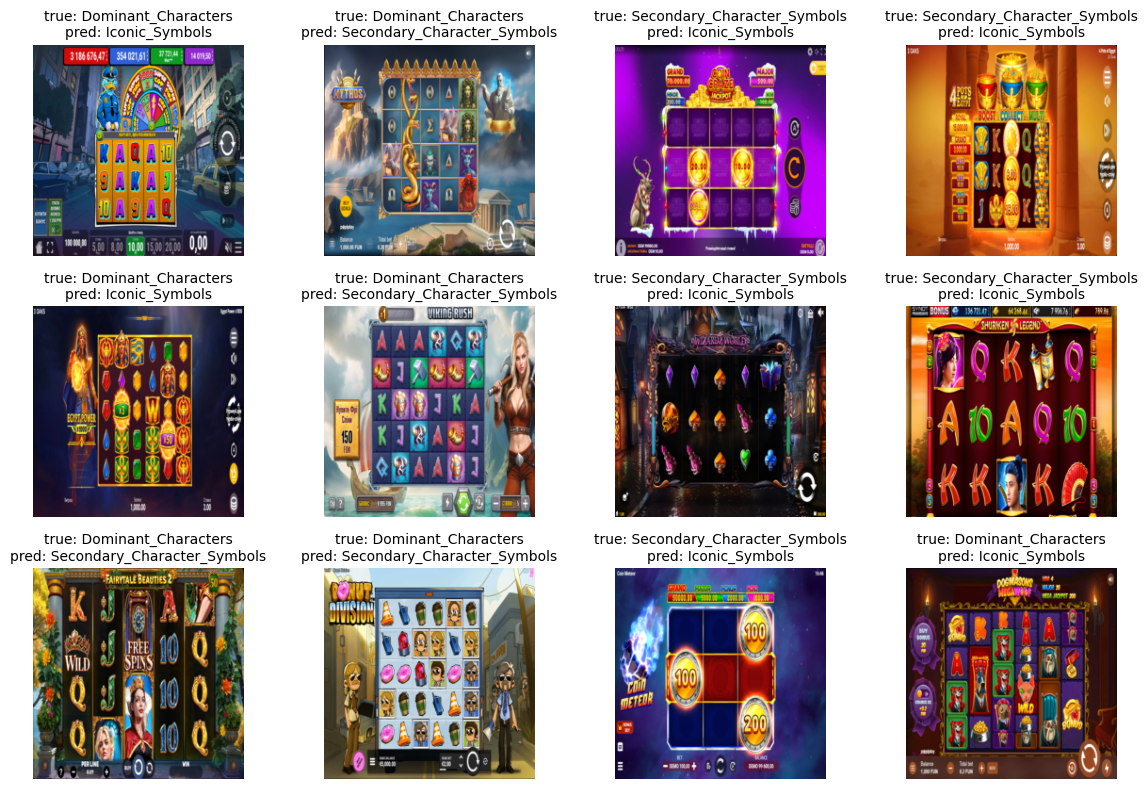

In [91]:
N = min(12, len(errors))

plt.figure(figsize=(12, 8))

for i in range(N):
    img, true, pred = errors[i]

    img = img.permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"true: {train_dataset.classes[true]}\n"
        f"pred: {train_dataset.classes[pred]}",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Inspect the Current Project Directory

Display the current working directory and nearby files. This helps verify which project folder the notebook is currently using.

In [50]:
print("Current working dir (cwd):", os.getcwd())
print("Files here:", os.listdir(".")[:20])
print("This notebook root contains 'ErgoVision AI' folder?:", (Path(".") / "ErgoVision AI").exists())

Current working dir (cwd): c:\Users\ermak\Desktop\slot_style_classifier — копия (2)\notebooks
Files here: ['.ipynb_checkpoints', '01_dataset_check.ipynb.ipynb', 'slot_style_classifier_new.ipynb', 'slot_style_dinamic.ipynb']
This notebook root contains 'ErgoVision AI' folder?: False
